# Full data

## Parse data

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as Func
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

### Загрузка и распаршивание

**Формат данных:** в файле `wifi_data_set_after_preprocessing.csv` каждая строка имеет вид `exp_num:[[dev1], [dev2], [dev3]]:label`<br><br>
*exp_num*: номер эксперимента (100 пакетов соответствуют ~ 5 секундам)<br>

*dev_*: номер датчика (всего 3)<br>

label: метка с целевой информацией <br>
- 0: движения не было, человек в кадре не находился
- 1: движение на расстоянии 1 метр от приемников
- 2: движение на расстоянии 2 метр от приемников
- 3: движение на расстоянии 3 метр от приемников

In [13]:
def parse_csv_line(line):
    line = line.strip()
    if not line:
        return None, None
    match = re.search(r':\[\[(.*?)\]\]:(.*?)$', line)
    if not match:
        return None, None
    content = match.group(1)
    label_str = match.group(2).strip()
    try:
        label = int(float(label_str))
    except ValueError:
        return None, None
    parts = content.split('],[')
    if len(parts) != 3:
        return None, None
    all_numbers = []
    for part in parts:
        part = part.strip('[').strip(']')
        numbers = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', part)
        if not numbers:
            return None, None
        try:
            values = [float(x) for x in numbers]
        except ValueError:
            return None, None
        all_numbers.extend(values)
    expected_len = 3 * 52 * 100
    if len(all_numbers) < expected_len:
        return None, None
    data = np.array(all_numbers[:expected_len])
    data = data.reshape(3, 100, 52).transpose(1, 2, 0)
    return data, label

def load_csv_data(csv_path):
    segments = []
    labels = []
    with open(csv_path, 'r') as f:
        for line in tqdm(f, desc="Parsing CSV"):
            seg, lbl = parse_csv_line(line)
            if seg is not None:
                segments.append(seg)
                labels.append(lbl)
    return np.array(segments), np.array(labels)

In [ ]:
csv_file = "processed_data/wifi_data_set_after_preprocessing.csv"
X, y = load_csv_data(csv_file)
print(f"Loaded {len(X)} samples, shape: {X.shape}")
print(f"Labels distribution: {np.unique(y, return_counts=True)}")
print(f"NaN in data: {np.isnan(X).any()}, Inf: {np.isinf(X).any()}")

Parsing CSV: 1600it [00:10, 155.91it/s]


Loaded 1599 samples, shape: (1599, 100, 52, 3)
Labels distribution: (array([0, 1, 2, 3]), array([399, 400, 400, 400]))
NaN in data: False, Inf: False


### Выделение тренировочного набора

Разделение на тренировочный \ валидационный \ тестовый наборы данных

По умолчанию соотношение 0.8 \ 0.1 \ 0.1

`Примечание:` в исходном наборе соотношение целевых меток одинаквое, но для обобщения на другие наборы данных используется стратификация

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (1279, 100, 52, 3), Val: (160, 100, 52, 3), Test: (160, 100, 52, 3)


### Нормализация

Нормализация производится по каждой поднесущей внутри отдельного приемника по тренировочному набору данных. Для воспроизводимости модели и использования для предсказания на новых данных параметры нормализации сохраняются в *scalers.pkl*

In [ ]:
n_devices = X_train.shape[3]
n_subcarriers = X_train.shape[2]
scalers = [[StandardScaler() for _ in range(n_subcarriers)] for _ in range(n_devices)]

for d in range(n_devices):
    for f in range(n_subcarriers):
        feature_data = X_train[:, :, f, d].reshape(-1, 1)
        scalers[d][f].fit(feature_data)

def normalize_data_per_subcarrier(X, scalers):
    X_norm = np.zeros_like(X)
    n_devices = len(scalers)
    n_subcarriers = len(scalers[0])
    for d in range(n_devices):
        for f in range(n_subcarriers):
            flat = X[:, :, f, d].reshape(-1, 1)
            norm_flat = scalers[d][f].transform(flat)
            X_norm[:, :, f, d] = norm_flat.reshape(X.shape[0], X.shape[1])
    return X_norm

X_train_norm = normalize_data_per_subcarrier(X_train, scalers)
X_val_norm = normalize_data_per_subcarrier(X_val, scalers)
X_test_norm = normalize_data_per_subcarrier(X_test, scalers)
print("Normalization complete")

Normalization complete


In [20]:
import pickle
with open('scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)
print("scalers saved to scalers.pkl")

scalers saved to scalers.pkl


## Visualization

### Среднее по устройствам

Визуализация средних амплитуд по всем поднесущим для каждого датчика

`Ось x:` номер пакета
`Ось y:` амплитуда

На гистограмме средние амплитуды по каждой поднесущей

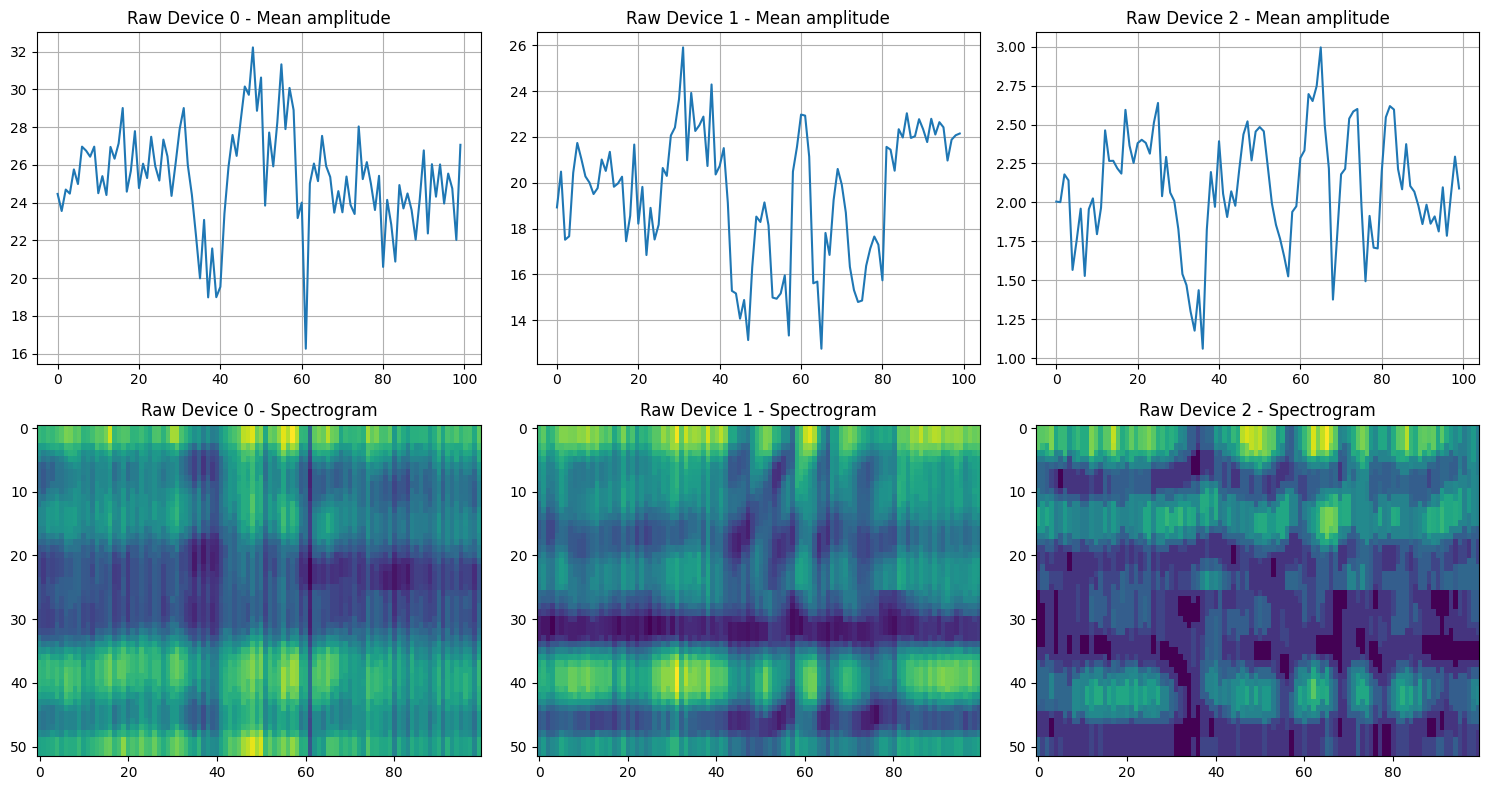

In [ ]:
sample_idx = np.random.randint(0, len(X_train))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for d in range(3):
    raw_sample = X_train[sample_idx, :, :, d]
    norm_sample = X_train_norm[sample_idx, :, :, d]
    
    axes[0, d].plot(np.mean(raw_sample, axis=1))
    axes[0, d].set_title(f'Raw Device {d} - Mean amplitude')
    axes[0, d].grid(True)
    
    axes[1, d].imshow(raw_sample.T, aspect='auto', cmap='viridis')
    axes[1, d].set_title(f'Raw Device {d} - Spectrogram')

plt.tight_layout()
plt.show()

### Среднее после нормализации

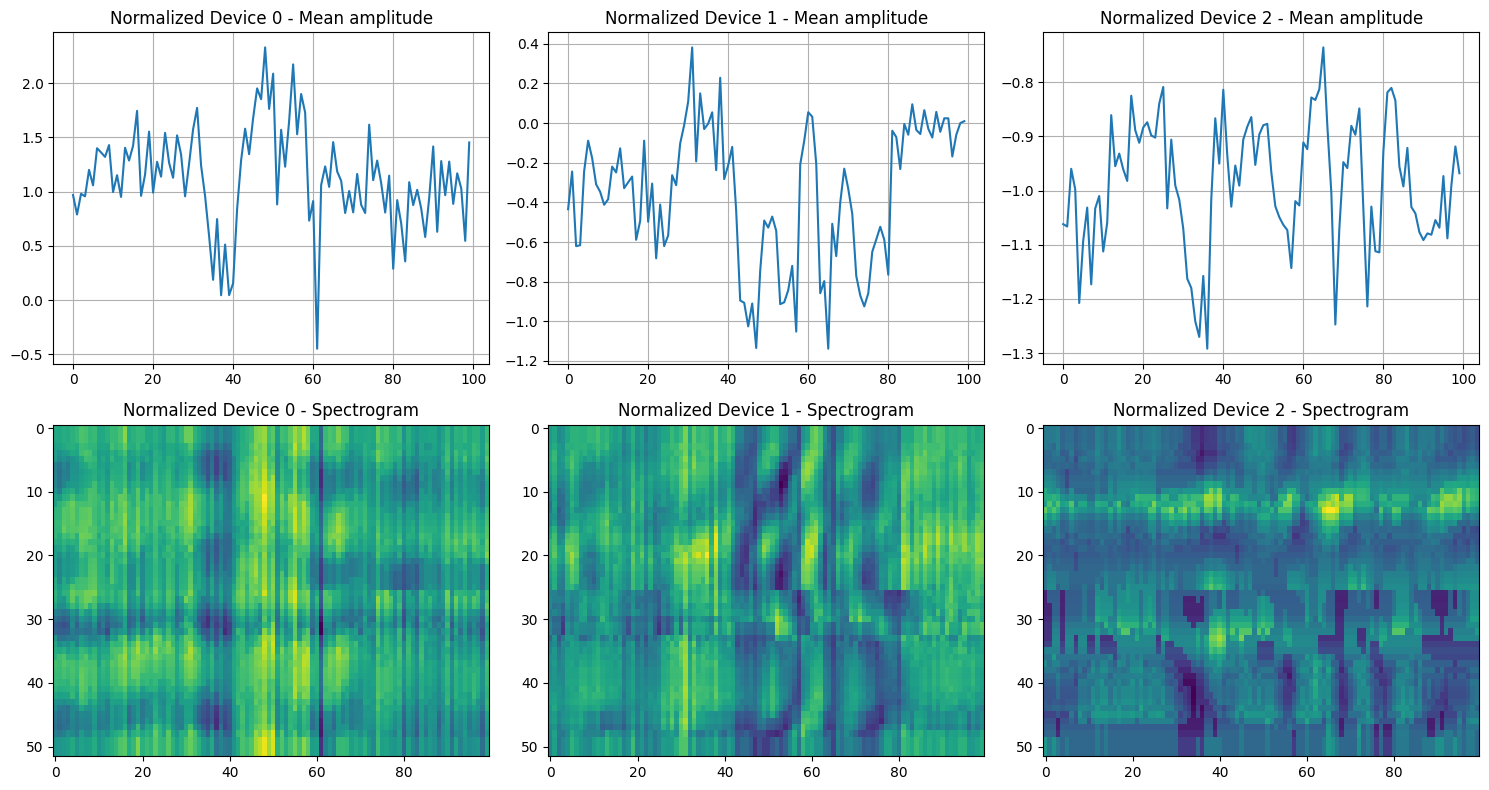

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for d in range(3):
    raw_sample = X_train[sample_idx, :, :, d]
    norm_sample = X_train_norm[sample_idx, :, :, d]
    
    axes[0, d].plot(np.mean(norm_sample, axis=1))
    axes[0, d].set_title(f'Normalized Device {d} - Mean amplitude')
    axes[0, d].grid(True)
    
    axes[1, d].imshow(norm_sample.T, aspect='auto', cmap='viridis')
    axes[1, d].set_title(f'Normalized Device {d} - Spectrogram')

plt.tight_layout()
plt.show()

### Визуализация 3-х семплов

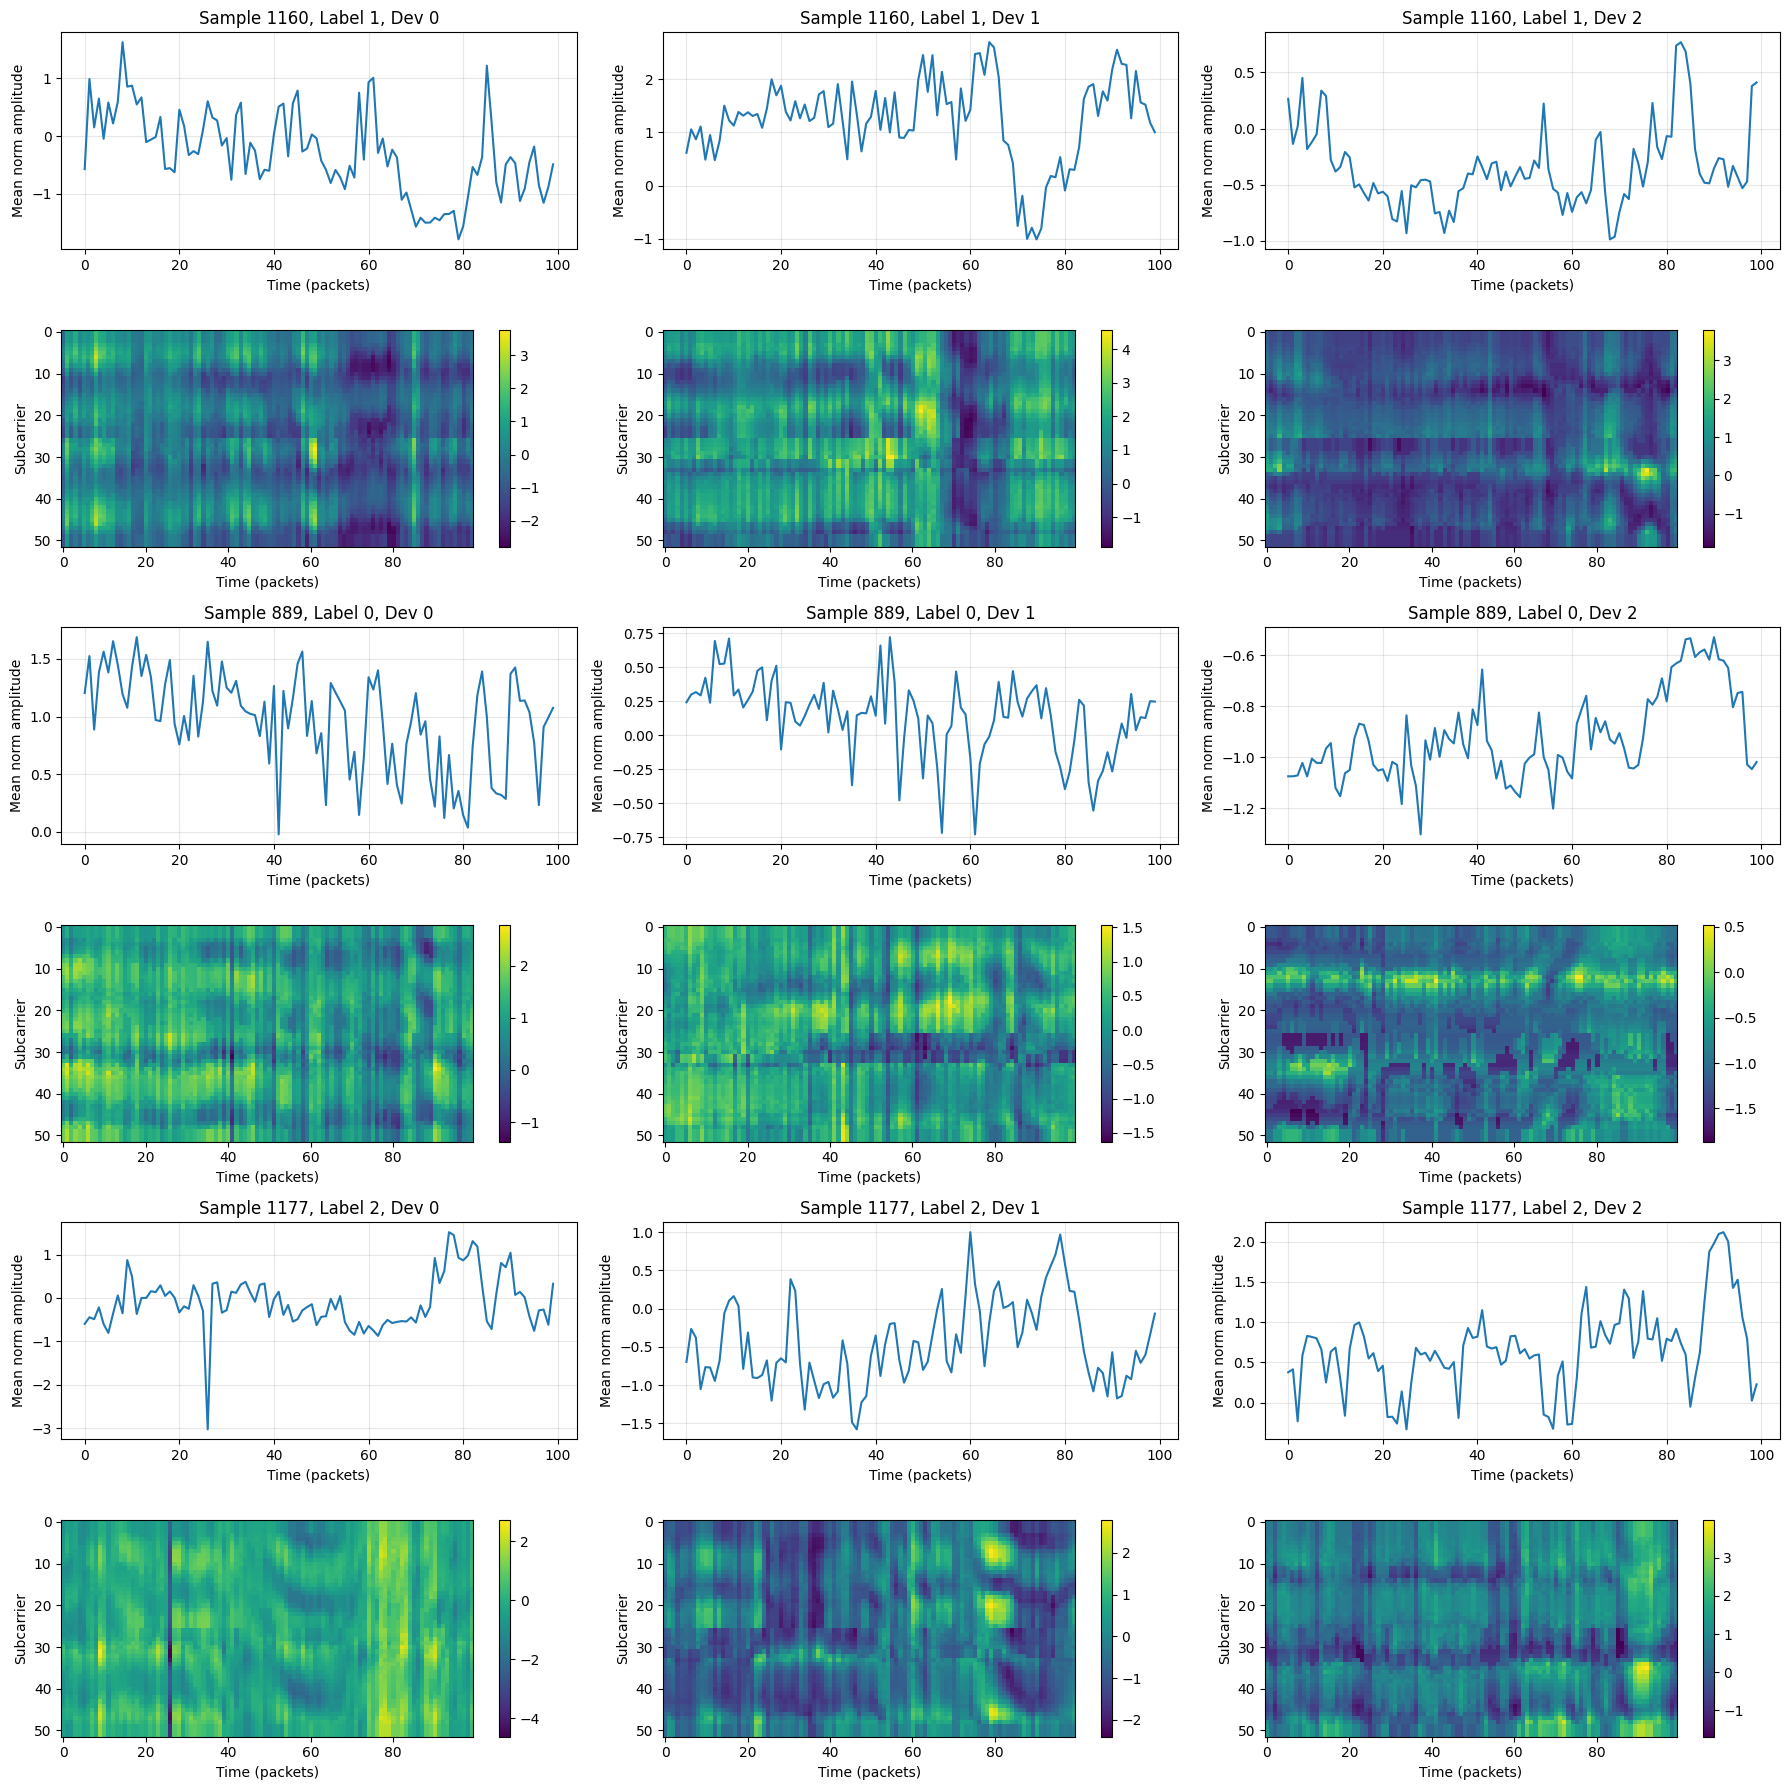

In [ ]:
random_indices = np.random.choice(len(X_train_norm), size=3, replace=False)

fig, axes = plt.subplots(6, 3, figsize=(18, 18))

for row_idx, idx in enumerate(random_indices):
    sample = X_train_norm[idx]
    label = y_train[idx]
    
    for dev in range(3):
        ax_line = axes[row_idx * 2, dev]
        ax_spec = axes[row_idx * 2 + 1, dev]
        
        dev_data = sample[:, :, dev]
        mean_amp = np.mean(dev_data, axis=1)
        ax_line.plot(mean_amp, linewidth=1.5)
        ax_line.set_title(f'Sample {idx}, Label {label}, Dev {dev}')
        ax_line.set_xlabel('Time (packets)')
        ax_line.set_ylabel('Mean norm amplitude')
        ax_line.grid(True, alpha=0.3)
        
        im = ax_spec.imshow(dev_data.T, aspect='auto', cmap='viridis')
        ax_spec.set_xlabel('Time (packets)')
        ax_spec.set_ylabel('Subcarrier')
        plt.colorbar(im, ax=ax_spec)

plt.tight_layout()
plt.show()

# Per person

In [1]:
# %%
import numpy as np
import pandas as pd
import re
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
import pickle
import matplotlib.pyplot as plt

def parse_csv_line(line):
    line = line.strip()
    if not line:
        return None, None
    match = re.search(r':\[\[(.*?)\]\]:(.*?)$', line)
    if not match:
        return None, None
    content = match.group(1)
    label_str = match.group(2).strip()
    try:
        label = int(float(label_str))
    except ValueError:
        return None, None
    parts = content.split('],[')
    if len(parts) != 3:
        return None, None
    all_numbers = []
    for part in parts:
        part = part.strip('[').strip(']')
        numbers = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', part)
        if not numbers:
            return None, None
        try:
            values = [float(x) for x in numbers]
        except ValueError:
            return None, None
        all_numbers.extend(values)
    expected_len = 3 * 52 * 100
    if len(all_numbers) < expected_len:
        return None, None
    data = np.array(all_numbers[:expected_len])
    data = data.reshape(3, 100, 52).transpose(1, 2, 0)
    return data, label

def load_csv_file(filepath):
    segments = []
    labels = []
    with open(filepath, 'r') as f:
        for line in tqdm(f, desc=f"Loading {filepath}"):
            seg, lbl = parse_csv_line(line)
            if seg is not None:
                segments.append(seg)
                labels.append(lbl)
    return np.array(segments), np.array(labels)

In [2]:
# %%
files = {
    1: "./processed_data/wifi_data_set_after_preprocessing_person_id_1.csv",
    2: "./processed_data/wifi_data_set_after_preprocessing_person_id_2.csv",
    3: "./processed_data/wifi_data_set_after_preprocessing_person_id_3.csv",
    4: "./processed_data/wifi_data_set_after_preprocessing_person_id_4.csv"
}

data_by_person = {}
for pid, fname in files.items():
    X, y = load_csv_file(fname)
    data_by_person[pid] = {'X': X, 'y': y}
    print(f"Person {pid}: {X.shape}, labels {np.unique(y, return_counts=True)}")

Loading ./processed_data/wifi_data_set_after_preprocessing_person_id_1.csv: 400it [00:03, 129.01it/s]


Person 1: (400, 100, 52, 3), labels (array([0, 1, 2, 3]), array([100, 100, 100, 100]))


Loading ./processed_data/wifi_data_set_after_preprocessing_person_id_2.csv: 400it [00:03, 118.87it/s]


Person 2: (400, 100, 52, 3), labels (array([0, 1, 2, 3]), array([100, 100, 100, 100]))


Loading ./processed_data/wifi_data_set_after_preprocessing_person_id_3.csv: 400it [00:02, 144.66it/s]


Person 3: (400, 100, 52, 3), labels (array([0, 1, 2, 3]), array([100, 100, 100, 100]))


Loading ./processed_data/wifi_data_set_after_preprocessing_person_id_4.csv: 400it [00:02, 175.71it/s]


Person 4: (400, 100, 52, 3), labels (array([0, 1, 2, 3]), array([100, 100, 100, 100]))


In [25]:
# %%
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
import matplotlib.pyplot as plt

X_all = np.concatenate([data_by_person[pid]['X'] for pid in [1,2,3,4]], axis=0)
y_all = np.concatenate([data_by_person[pid]['y'] for pid in [1,2,3,4]], axis=0)

X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (1280, 100, 52, 3), Val: (160, 100, 52, 3), Test: (160, 100, 52, 3)


In [26]:
# %%
n_devices = X_train.shape[3]
n_subcarriers = X_train.shape[2]
scalers = [[StandardScaler() for _ in range(n_subcarriers)] for _ in range(n_devices)]

for d in range(n_devices):
    for f in range(n_subcarriers):
        feature_data = X_train[:, :, f, d].reshape(-1, 1)
        scalers[d][f].fit(feature_data)

def normalize_data_per_subcarrier(X, scalers):
    X_norm = np.zeros_like(X)
    n_devices = len(scalers)
    n_subcarriers = len(scalers[0])
    for d in range(n_devices):
        for f in range(n_subcarriers):
            flat = X[:, :, f, d].reshape(-1, 1)
            norm_flat = scalers[d][f].transform(flat)
            X_norm[:, :, f, d] = norm_flat.reshape(X.shape[0], X.shape[1])
    return X_norm

X_train_norm = normalize_data_per_subcarrier(X_train, scalers)
X_val_norm = normalize_data_per_subcarrier(X_val, scalers)
X_test_norm = normalize_data_per_subcarrier(X_test, scalers)

print("Normalization complete")

Normalization complete


In [27]:
# %%
with open('scalers_person_split.pkl', 'wb') as f:
    pickle.dump(scalers, f)

np.savez_compressed('train_data.npz', X=X_train_norm, y=y_train)
np.savez_compressed('val_data.npz', X=X_val_norm, y=y_val)
np.savez_compressed('test_data.npz', X=X_test_norm, y=y_test)

print("Data saved")

Data saved


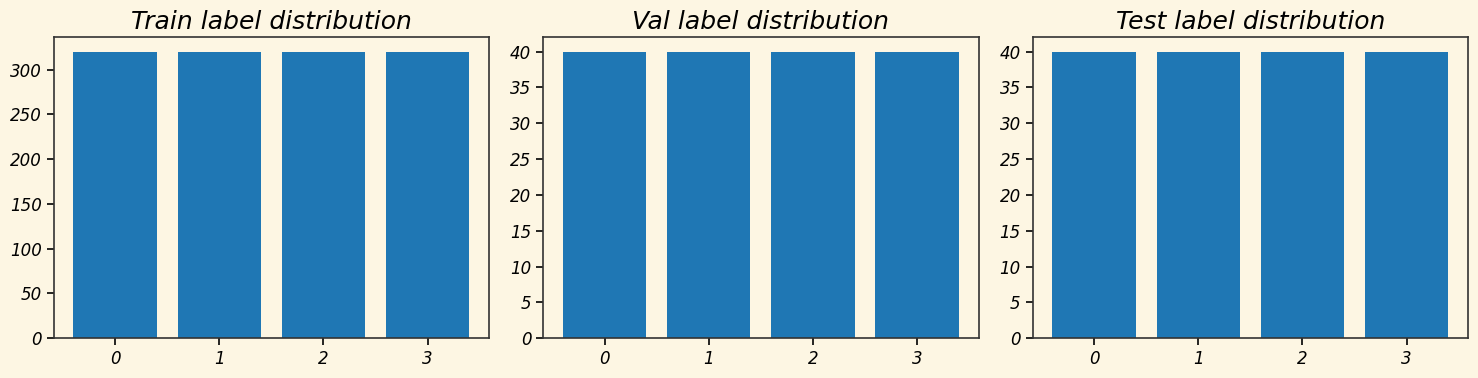

In [28]:
# %%
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, y) in enumerate([('Train', y_train), ('Val', y_val), ('Test', y_test)]):
    unique, counts = np.unique(y, return_counts=True)
    axes[i].bar(unique.astype(str), counts)
    axes[i].set_title(f'{name} label distribution')
plt.tight_layout()
plt.show()

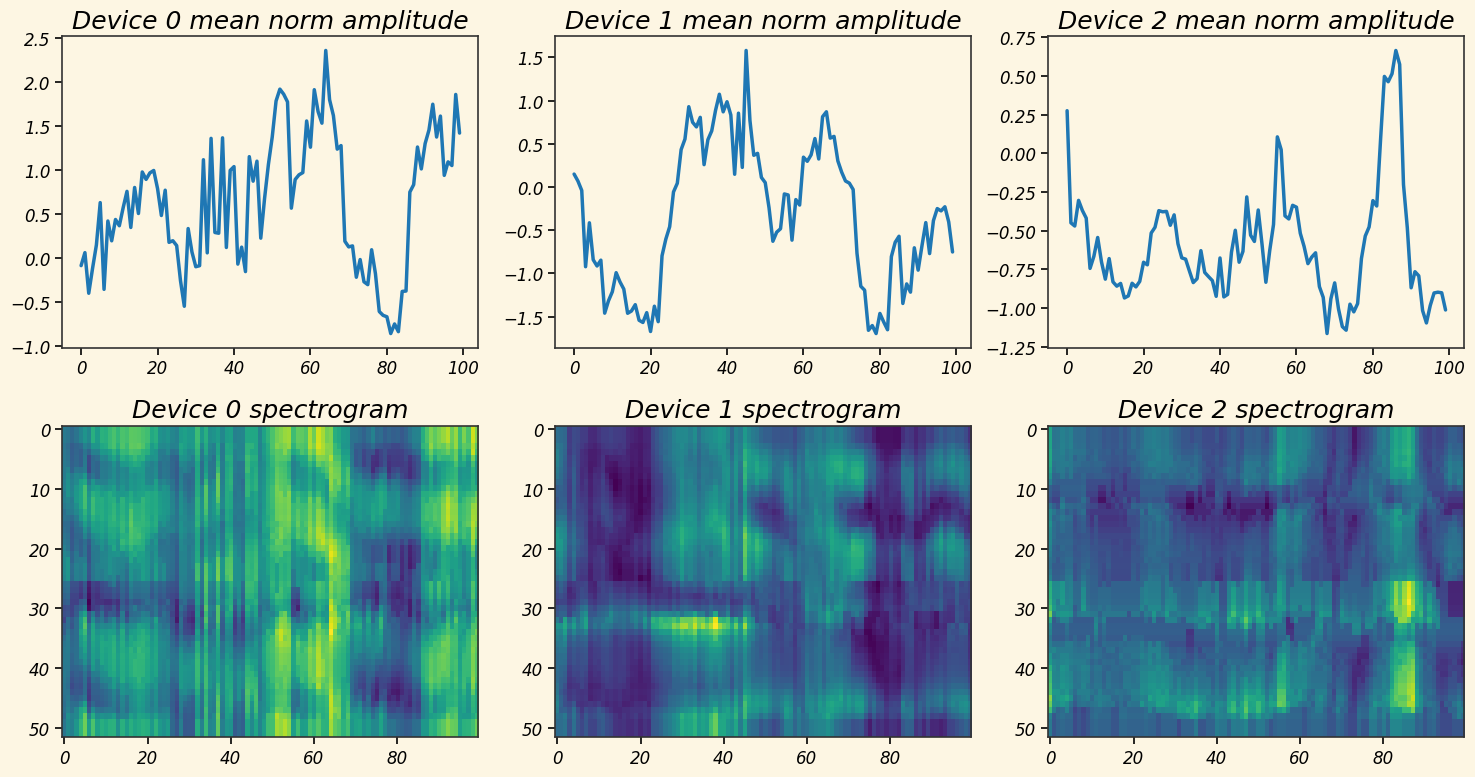

In [29]:
# %%
sample_idx = np.random.randint(0, len(X_train_norm))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for d in range(3):
    sample = X_train_norm[sample_idx, :, :, d]
    axes[0, d].plot(np.mean(sample, axis=1))
    axes[0, d].set_title(f'Device {d} mean norm amplitude')
    axes[1, d].imshow(sample.T, aspect='auto', cmap='viridis')
    axes[1, d].set_title(f'Device {d} spectrogram')
plt.tight_layout()
plt.show()

# Model

## Dataset

Принимаемые значения присоздании объекта:

- *segments:* 100 пакетов на каждый пример. Для CNN+LSTM на ненормализованные данные дают прирост f1 ~ 2% на тесте при тех же параметрах, для mamba(s6) подаются ненормализованные данные (внутри модели проходит rms нормализация)
- *labels:* target, сразу извлевается метка для бинарной классификации и для классификации расстояния

In [70]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

In [71]:
class CSIDataset(Dataset):
    def __init__(self, segments, labels):
        self.segments = torch.FloatTensor(segments)
        self.labels = torch.LongTensor(labels)
        self.motion_labels = (self.labels > 0).long()
    
    def __len__(self):
        return len(self.segments)
    
    def __getitem__(self, idx):
        x = self.segments[idx]
        return x, self.motion_labels[idx], self.labels[idx]

train_dataset = CSIDataset(X_train, y_train)
val_dataset = CSIDataset(X_val, y_val)
test_dataset = CSIDataset(X_test, y_test)

BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## CNN+LSTM

### Model

**Конфигурация CNN (самое важное):**

- DATA_TYPE: "stack", если подается вектор конкатенации поднесущих 3-х устройств [esp1(shape n_subcarry x 1), esp2(shape n_subcarry x 1), esp3(shape n_subcarry x 1)], "avg" для усредненного вектора (shape n_subcarry x 1)
- CONV1_FILTERS: глубина свертки
- NUM_LAYERS: количество LSTM блоков в модели
- HIDDEN_SIZE: размерность h (вектора внутреннего состояния) LSTM
- DROPOUT: отбрасывается указанная доля входных сигналов (действует как регуляризация)
- ATTENTION_SIZE: размерность слоя внимания
- WEIGHT_DECAY: уровень регуляризации (1е-4 - 1е-3)
- EPOCHS: максимальное число эпох
- EARLY_STOP_PATIENCE: после данного числа эпох без улучшения сработает ранняя остановка
- MOTION_LOSS_WEIGHT, DISTANCE_LOSS_WEIGHT: веса каждой из задач при расчете функции потерь

In [ ]:
class ConfigCNN:
    DATA_TYPE = "stack"
    N_SUBCARRIERS = 52
    N_MOTION_CLASSES = 2
    N_DISTANCE_CLASSES = 4
    CONV1_FILTERS = 64
    CONV1_KERNEL = 3
    CONV2_FILTERS = 128
    CONV2_KERNEL = 3
    HIDDEN_SIZE = 64
    NUM_LAYERS = 2
    DROPOUT = 0.35
    BIDIRECTIONAL = True
    USE_ATTENTION = True
    ATTENTION_SIZE = 64
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 5e-4
    EPOCHS = 50
    GRAD_CLIP = 1.0
    EARLY_STOP_PATIENCE = 10
    MOTION_LOSS_WEIGHT = 1.0
    DISTANCE_LOSS_WEIGHT = 1.5

class TemporalAttention(nn.Module):
    def __init__(self, hidden_size, attention_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, attention_size),
            nn.Tanh(),
            nn.Linear(attention_size, 1)
        )
    def forward(self, lstm_output):
        weights = self.attention(lstm_output).squeeze(-1)
        weights = Func.softmax(weights, dim=1)
        context = torch.sum(lstm_output * weights.unsqueeze(-1), dim=1)
        return context, weights

class CSI_CNN_LSTM_Attention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        input_channels = config.N_SUBCARRIERS * 3
        self.conv1 = nn.Conv1d(input_channels, config.CONV1_FILTERS,
                               kernel_size=config.CONV1_KERNEL, padding='same')
        self.bn1 = nn.BatchNorm1d(config.CONV1_FILTERS)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(config.CONV1_FILTERS, config.CONV2_FILTERS,
                               kernel_size=config.CONV2_KERNEL, padding='same')
        self.bn2 = nn.BatchNorm1d(config.CONV2_FILTERS)
        self.pool2 = nn.MaxPool1d(2)
        self.lstm = nn.LSTM(
            input_size=config.CONV2_FILTERS,
            hidden_size=config.HIDDEN_SIZE,
            num_layers=config.NUM_LAYERS,
            batch_first=True,
            dropout=config.DROPOUT if config.NUM_LAYERS > 1 else 0,
            bidirectional=config.BIDIRECTIONAL
        )
        lstm_out_size = config.HIDDEN_SIZE * 2 if config.BIDIRECTIONAL else config.HIDDEN_SIZE
        self.use_attention = config.USE_ATTENTION
        if self.use_attention:
            self.attention = TemporalAttention(lstm_out_size, config.ATTENTION_SIZE)
            fc_in = lstm_out_size
        else:
            self.attention = None
            fc_in = lstm_out_size
        self.motion_head = nn.Sequential(
            nn.Linear(fc_in, 64),
            nn.ReLU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(64, config.N_MOTION_CLASSES)
        )
        self.distance_head = nn.Sequential(
            nn.Linear(fc_in, 64),
            nn.ReLU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(64, config.N_DISTANCE_CLASSES)
        )
    def forward(self, x):
        B, T, F, D = x.shape
        x = x.permute(0, 3, 2, 1).reshape(B, F * D, T)
        x = self.pool1(torch.nn.functional.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.nn.functional.relu(self.bn2(self.conv2(x))))
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        if self.use_attention:
            context, attn = self.attention(lstm_out)
        else:
            context = lstm_out[:, -1, :]
            attn = None
        motion_logits = self.motion_head(context)
        distance_logits = self.distance_head(context)
        return motion_logits, distance_logits, attn

### Trainer

Тренировочный класс настраивает цикл обучения, валидации, сохраняет модель и промежуточные результаты

In [73]:
class TrainerCNN:
    def __init__(self, model, config, device):
        self.model = model.to(device)
        self.config = config
        self.device = device
        self.criterion_motion = nn.CrossEntropyLoss()
        self.criterion_distance = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY
        )
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=5
        )
        self.best_val_acc = 0
        self.patience_counter = 0
        self.train_losses = []
        self.val_losses = []
        self.train_acc_motion = []
        self.train_acc_dist = []
        self.val_acc_motion = []
        self.val_acc_dist = []
    
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        correct_motion = 0
        correct_dist = 0
        total = 0
        for data, motion_target, dist_target in tqdm(train_loader, desc='Training'):
            data = data.to(self.device)
            motion_target = motion_target.to(self.device)
            dist_target = dist_target.to(self.device)
            self.optimizer.zero_grad()
            motion_out, dist_out, _ = self.model(data)
            loss_motion = self.criterion_motion(motion_out, motion_target)
            loss_dist = self.criterion_distance(dist_out, dist_target)
            loss = self.config.MOTION_LOSS_WEIGHT * loss_motion + self.config.DISTANCE_LOSS_WEIGHT * loss_dist
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.GRAD_CLIP)
            self.optimizer.step()
            total_loss += loss.item()
            total += motion_target.size(0)
            correct_motion += motion_out.argmax(1).eq(motion_target).sum().item()
            correct_dist += dist_out.argmax(1).eq(dist_target).sum().item()
        avg_loss = total_loss / len(train_loader)
        acc_motion = 100. * correct_motion / total
        acc_dist = 100. * correct_dist / total
        self.train_losses.append(avg_loss)
        self.train_acc_motion.append(acc_motion)
        self.train_acc_dist.append(acc_dist)
        return avg_loss, acc_motion, acc_dist
    
    @torch.no_grad()
    def validate(self, val_loader):
        self.model.eval()
        total_loss = 0
        correct_motion = 0
        correct_dist = 0
        total = 0
        for data, motion_target, dist_target in tqdm(val_loader, desc='Validation'):
            data = data.to(self.device)
            motion_target = motion_target.to(self.device)
            dist_target = dist_target.to(self.device)
            motion_out, dist_out, _ = self.model(data)
            loss_motion = self.criterion_motion(motion_out, motion_target)
            loss_dist = self.criterion_distance(dist_out, dist_target)
            loss = self.config.MOTION_LOSS_WEIGHT * loss_motion + self.config.DISTANCE_LOSS_WEIGHT * loss_dist
            total_loss += loss.item()
            total += motion_target.size(0)
            correct_motion += motion_out.argmax(1).eq(motion_target).sum().item()
            correct_dist += dist_out.argmax(1).eq(dist_target).sum().item()
        avg_loss = total_loss / len(val_loader)
        acc_motion = 100. * correct_motion / total
        acc_dist = 100. * correct_dist / total
        self.val_losses.append(avg_loss)
        self.val_acc_motion.append(acc_motion)
        self.val_acc_dist.append(acc_dist)
        return avg_loss, acc_motion, acc_dist
    
    def train(self, train_loader, val_loader, epochs):
        for epoch in range(epochs):
            train_loss, train_motion, train_dist = self.train_epoch(train_loader)
            val_loss, val_motion, val_dist = self.validate(val_loader)
            self.scheduler.step(val_loss)
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Motion: {train_motion:.2f}% Dist: {train_dist:.2f}% | "
                  f"Val Loss: {val_loss:.4f} | Motion: {val_motion:.2f}% Dist: {val_dist:.2f}%")
            val_acc_avg = (val_motion + val_dist) / 2
            if val_acc_avg > self.best_val_acc:
                self.best_val_acc = val_acc_avg
                self.patience_counter = 0
                torch.save(self.model.state_dict(), 'best_cnn_lstm.pth')
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.config.EARLY_STOP_PATIENCE:
                    print("Early stopping")
                    break

### Training visualization

Визуализация динамики потерь и точности модели на каждой эпохе

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

def plot_training_history(trainer, title="Training History"):
    try:
        fm.fontManager.addfont('IndieFlower.ttf')
        plt.rcParams['font.family'] = 'Indie Flower'
    except:
        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['font.style'] = 'italic'

    plt.rcParams.update({
        'font.size': 14,
        'axes.titlesize': 18,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'axes.edgecolor': '#333333',
        'axes.linewidth': 1.2,
        'xtick.major.width': 1.2,
        'ytick.major.width': 1.2,
        'xtick.major.size': 5,
        'ytick.major.size': 5,
        'grid.alpha': 0.3,
        'grid.linestyle': ':',
        'grid.linewidth': 0.5,
        'figure.facecolor': '#fdf6e3',
        'axes.facecolor': '#fdf6e3',
        'lines.linewidth': 2.5,
        'lines.markersize': 8,
        'lines.markeredgewidth': 1,
        'lines.solid_capstyle': 'round',
        'lines.solid_joinstyle': 'round'
    })

    def jitter(arr, scale=0.008):
        rng = np.max(arr) - np.min(arr)
        if rng == 0:
            rng = 1.0
        return arr + np.random.normal(0, scale * rng, size=len(arr))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    epochs = np.arange(1, len(trainer.train_losses) + 1)

    train_loss_j = jitter(np.array(trainer.train_losses))
    val_loss_j = jitter(np.array(trainer.val_losses))
    axes[0, 0].plot(epochs, train_loss_j, label='Train', marker='o', markersize=6)
    axes[0, 0].plot(epochs, val_loss_j, label='Val', marker='s', markersize=6)
    axes[0, 0].set_title(f'{title} - Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    legend = axes[0, 0].legend(frameon=True, fancybox=True, framealpha=0.9, edgecolor='#aaaaaa')
    legend.get_frame().set_linewidth(0.8)
    axes[0, 0].grid(True)

    train_mot_j = jitter(np.array(trainer.train_acc_motion))
    val_mot_j = jitter(np.array(trainer.val_acc_motion))
    axes[0, 1].plot(epochs, train_mot_j, label='Train Motion', marker='o', markersize=6)
    axes[0, 1].plot(epochs, val_mot_j, label='Val Motion', marker='s', markersize=6)
    axes[0, 1].set_title(f'{title} - Motion Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    legend = axes[0, 1].legend(frameon=True, fancybox=True, framealpha=0.9, edgecolor='#aaaaaa')
    legend.get_frame().set_linewidth(0.8)
    axes[0, 1].grid(True)

    train_dist_j = jitter(np.array(trainer.train_acc_dist))
    val_dist_j = jitter(np.array(trainer.val_acc_dist))
    axes[1, 0].plot(epochs, train_dist_j, label='Train Distance', marker='o', markersize=6)
    axes[1, 0].plot(epochs, val_dist_j, label='Val Distance', marker='s', markersize=6)
    axes[1, 0].set_title(f'{title} - Distance Accuracy')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy (%)')
    legend = axes[1, 0].legend(frameon=True, fancybox=True, framealpha=0.9, edgecolor='#aaaaaa')
    legend.get_frame().set_linewidth(0.8)
    axes[1, 0].grid(True)

    axes[1, 1].axis('off')
    plt.tight_layout()
    plt.show()

### Evaluate

Валидация модели на тренировочном наборе данных (универсальная для CNN+LSTM и  Mamba моделей)

In [75]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, test_loader, device, model_name="Model", is_mamba=False):
    if is_mamba:
        model.load_state_dict(torch.load('best_mamba_model.pth', map_location=device))
    else:
        model.load_state_dict(torch.load('best_cnn_lstm.pth', map_location=device))
    model.eval()
    
    all_motion_pred, all_motion_true = [], []
    all_dist_pred, all_dist_true = [], []
    
    with torch.no_grad():
        for data, m_target, d_target in tqdm(test_loader, desc=f'Evaluating {model_name}'):
            data = data.to(device)
            if is_mamba:
                m_out, d_out = model(data)
            else:
                m_out, d_out, _ = model(data)
            all_motion_pred.extend(m_out.argmax(1).cpu().numpy())
            all_motion_true.extend(m_target.numpy())
            all_dist_pred.extend(d_out.argmax(1).cpu().numpy())
            all_dist_true.extend(d_target.numpy())
    
    print(f"\n{'='*50}")
    print(f"{model_name} - Motion Classification Report")
    print(classification_report(all_motion_true, all_motion_pred, target_names=['No movement', 'Movement']))
    
    print(f"\n{model_name} - Distance Classification Report")
    print(classification_report(all_dist_true, all_dist_pred, target_names=['0m', '1m', '2m', '3m']))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    cm_motion = confusion_matrix(all_motion_true, all_motion_pred)
    sns.heatmap(cm_motion, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['No move', 'Move'], yticklabels=['No move', 'Move'])
    axes[0].set_title(f'{model_name} - Motion Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    
    cm_dist = confusion_matrix(all_dist_true, all_dist_pred)
    sns.heatmap(cm_dist, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                xticklabels=['0m','1m','2m','3m'], yticklabels=['0m','1m','2m','3m'])
    axes[1].set_title(f'{model_name} - Distance Confusion Matrix')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    
    plt.tight_layout()
    plt.show()

Число параметров при данной конфигурации: 278983

In [76]:
cnn_config = ConfigCNN()
cnn_model = CSI_CNN_LSTM_Attention(cnn_config)
trainer_cnn = TrainerCNN(cnn_model, cnn_config, device)
trainer_cnn.train(train_loader, val_loader, cnn_config.EPOCHS)

Validation: 100%|██████████| 1/1 [00:00<00:00, 13.98it/s]


Epoch   1/50 | Train Loss: 2.6259 | Motion: 75.00% Dist: 38.59% | Val Loss: 2.6151 | Motion: 75.00% Dist: 25.00%


Validation: 100%|██████████| 1/1 [00:00<00:00, 14.91it/s]


Epoch   2/50 | Train Loss: 2.2291 | Motion: 91.17% Dist: 51.17% | Val Loss: 2.7064 | Motion: 75.00% Dist: 25.00%


Validation: 100%|██████████| 1/1 [00:00<00:00,  3.26it/s]


...

Epoch  43/50 | Train Loss: 0.0067 | Motion: 100.00% Dist: 100.00% | Val Loss: 0.2919 | Motion: 99.38% Dist: 97.50%


Validation: 100%|██████████| 1/1 [00:00<00:00, 21.45it/s]


Epoch  44/50 | Train Loss: 0.0062 | Motion: 100.00% Dist: 100.00% | Val Loss: 0.2460 | Motion: 100.00% Dist: 97.50%


Validation: 100%|██████████| 1/1 [00:00<00:00, 21.59it/s]

Epoch  45/50 | Train Loss: 0.0064 | Motion: 100.00% Dist: 100.00% | Val Loss: 0.1642 | Motion: 100.00% Dist: 98.12%
Early stopping


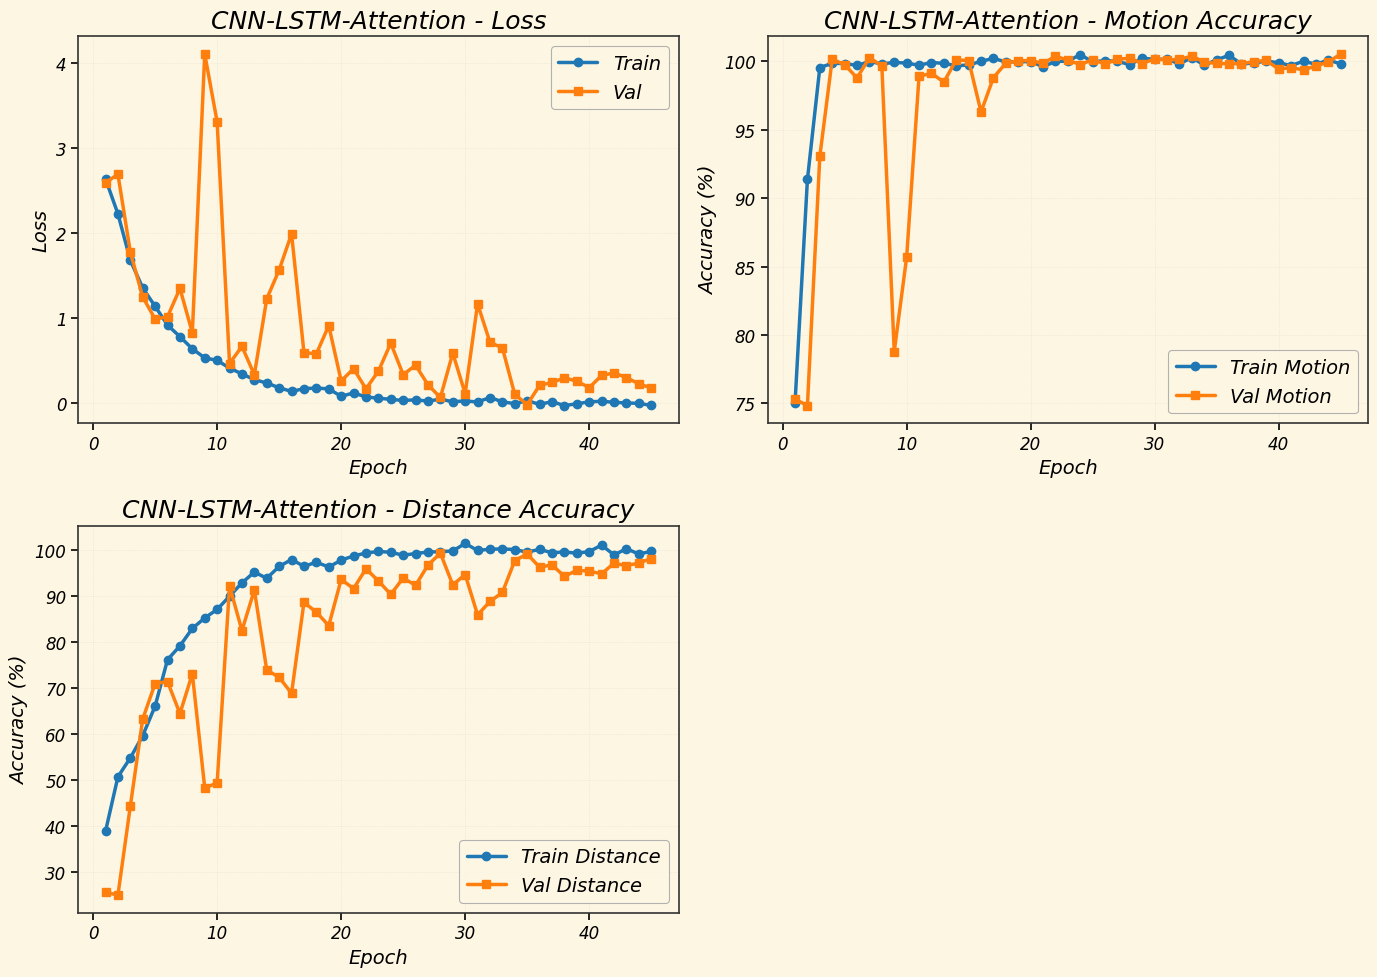

In [77]:
plot_training_history(trainer_cnn, title="CNN-LSTM-Attention")

Evaluating CNN-LSTM-Attention: 100%|██████████| 1/1 [00:00<00:00, 15.96it/s]



CNN-LSTM-Attention - Motion Classification Report
              precision    recall  f1-score   support

 No movement       1.00      1.00      1.00        40
    Movement       1.00      1.00      1.00       120

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160


CNN-LSTM-Attention - Distance Classification Report
              precision    recall  f1-score   support

          0m       1.00      1.00      1.00        40
          1m       0.95      1.00      0.98        40
          2m       0.97      0.95      0.96        40
          3m       1.00      0.97      0.99        40

    accuracy                           0.98       160
   macro avg       0.98      0.98      0.98       160
weighted avg       0.98      0.98      0.98       160



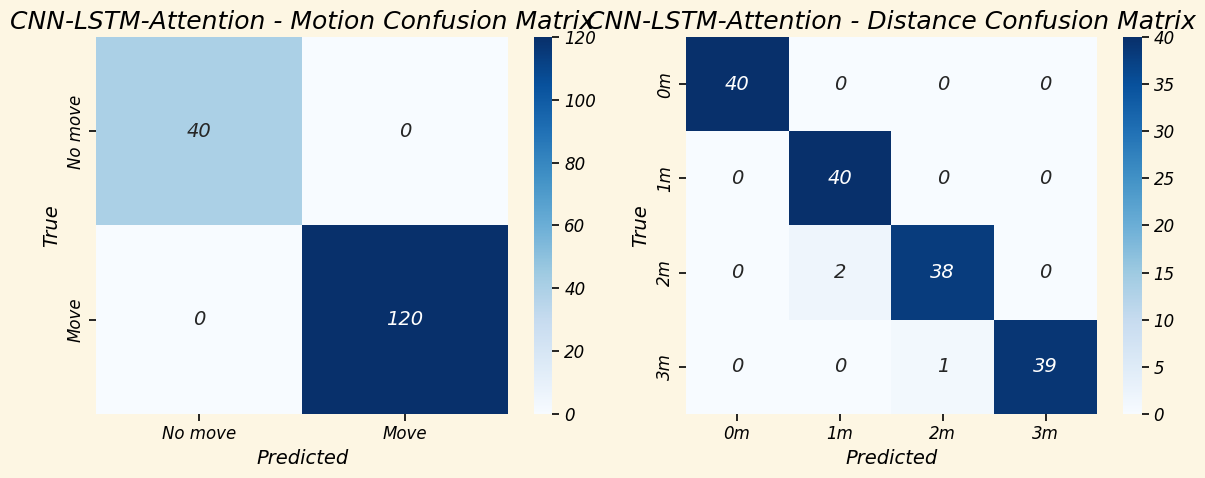

In [79]:
# %%
evaluate_model(cnn_model, test_loader, device, model_name="CNN-LSTM-Attention", is_mamba=False)

## Mamba(S6)

**Конфигурация Mamba (самое важное):**

- DATA_TYPE: "stack", если подается вектор конкатенации поднесущих 3-х устройств [esp1(shape n_subcarry x 1), esp2(shape n_subcarry x 1), esp3(shape n_subcarry x 1)], "avg" для усредненного вектора (shape n_subcarry x 1)
- WINDOW_SIZE: размер окна для рекуррентной модели (на выходе используется конкатеницая всех скрытых состояний)
- N_FEATURES: количество поднесущих
- D_MODEL: размерность выходного вектора и промежуточных состояний в mamba
- N_LAYERS: количество Mamba+CNN блоков в модели
- HIDDEN_SIZE: размерность h (вектора внутреннего состояния) LSTM
- DROPOUT: отбрасывается указанная доля входных сигналов (действует как регуляризация)
- WEIGHT_DECAY: уровень регуляризации (1е-4 - 1е-3)
- EPOCHS: максимальное число эпох
- EARLY_STOP_PATIENCE: после данного числа эпох без улучшения сработает ранняя остановка
- MOTION_LOSS_WEIGHT, DISTANCE_LOSS_WEIGHT: веса каждой из задач при расчете функции потерь

In [54]:
class ConfigMamba:
    DATA_TYPE = "stack"
    WINDOW_SIZE = 100
    N_FEATURES = 52
    BATCH_SIZE = 256
    LEARNING_RATE = 1e-3
    EPOCHS = 100
    D_MODEL = 32
    N_LAYERS = 2
    D_STATE = 16
    DT_RANK = 4
    D_CONV = 4
    EXPAND_FACTOR = 2.0
    N_HEADS = 4
    DROPOUT = 0.5
    WEIGHT_DECAY = 5e-4
    GRAD_CLIP = 1.0
    EARLY_STOP_PATIENCE = 15
    N_MOTION_CLASSES = 2
    N_DISTANCE_CLASSES = 4
    MOTION_LOSS_WEIGHT = 1.0
    DISTANCE_LOSS_WEIGHT = 1.5
    INPUT_CONV_KERNEL = 7
    POOL_SIZE = 2

### Dataset

In [55]:
class CSIDataset(Dataset):
    def __init__(self, segments, labels):
        self.segments = torch.FloatTensor(segments)
        self.labels = torch.LongTensor(labels)
        self.motion_labels = (self.labels > 0).long()
    
    def __len__(self):
        return len(self.segments)
    
    def __getitem__(self, idx):
        x = self.segments[idx]
        return x, self.motion_labels[idx], self.labels[idx]

### Model

In [ ]:
class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d))
    def forward(self, x):
        rms = torch.sqrt(torch.mean(x**2, dim=-1, keepdim=True) + self.eps)
        return x / rms * self.weight

class SelectiveSSM(nn.Module):
    def __init__(self, d_model, d_state=16, dt_rank=None, delta_softplus=True):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.dt_rank = dt_rank if dt_rank is not None else max(1, d_model // 16)
        self.delta_softplus = delta_softplus
        self.x_proj = nn.Linear(d_model, self.dt_rank + d_state * 2, bias=False)
        self.dt_proj = nn.Linear(self.dt_rank, 1)
        self.x_proj_state = nn.Linear(d_model, d_state, bias=False)
        A = torch.arange(1, d_state + 1).float().view(1, d_state)
        A = -torch.exp(A)
        self.A_log = nn.Parameter(torch.log(-A))
        self.out_proj = nn.Linear(d_state, d_model, bias=False)
        self.D = nn.Parameter(torch.ones(d_model))
    def forward(self, x):
        B, L, D = x.shape
        N = self.d_state
        proj = self.x_proj(x)
        dt_rank_part = proj[..., :self.dt_rank]
        B_part = proj[..., self.dt_rank:self.dt_rank + N]
        C_part = proj[..., self.dt_rank + N:]
        dt = self.dt_proj(dt_rank_part)
        if self.delta_softplus:
            dt = Func.softplus(dt)
        A = -torch.exp(self.A_log)
        A_bar = torch.exp(dt * A)
        B_bar = dt * B_part
        x_state = self.x_proj_state(x)
        h = torch.zeros(B, N, device=x.device, dtype=x.dtype)
        outputs = []
        for t in range(L):
            h = A_bar[:, t] * h + B_bar[:, t] * x_state[:, t]
            y_t = self.out_proj(h * C_part[:, t])
            outputs.append(y_t.unsqueeze(1))
        y = torch.cat(outputs, dim=1)
        y = y + self.D * x
        return y

class MambaBranch(nn.Module):
    def __init__(self, d_model, d_state=16, expand_factor=2, conv_kernel=4, dropout=0.1):
        super().__init__()
        self.norm = RMSNorm(d_model)
        d_inner = int(d_model * expand_factor)
        self.in_proj = nn.Linear(d_model, d_inner * 2, bias=False)
        self.conv1d = nn.Conv1d(d_inner, d_inner, kernel_size=conv_kernel, padding=conv_kernel-1, groups=d_inner)
        self.ssm = SelectiveSSM(d_inner, d_state)
        self.out_proj = nn.Linear(d_inner, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        residual = x
        x = self.norm(x)
        x_proj = self.in_proj(x)
        x_ssm, gate = x_proj.chunk(2, dim=-1)
        x_ssm = self.conv1d(x_ssm.transpose(1,2)).transpose(1,2)[:, :x.size(1), :]
        x_ssm = Func.silu(x_ssm)
        x_ssm = self.ssm(x_ssm)
        gate = Func.silu(gate)
        x = x_ssm * gate
        x = self.out_proj(x)
        x = self.dropout(x)
        return residual + x

class ConvBranch(nn.Module):
    def __init__(self, d_model, kernel_size=3, dropout=0.1):
        super().__init__()
        self.norm = RMSNorm(d_model)
        self.conv = nn.Conv1d(d_model, d_model, kernel_size=kernel_size, padding=kernel_size//2, groups=d_model)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        residual = x
        x = self.norm(x)
        x = self.conv(x.transpose(1,2)).transpose(1,2)
        x = self.act(x)
        x = self.dropout(x)
        return residual + x

class HybridMambaBlock(nn.Module):
    def __init__(self, d_model, d_state=16, expand_factor=2, conv_kernel=4, dropout=0.1):
        super().__init__()
        self.conv_branch = ConvBranch(d_model, kernel_size=3, dropout=dropout)
        self.mamba_branch = MambaBranch(d_model, d_state, expand_factor, conv_kernel, dropout)
    def forward(self, x):
        x = self.conv_branch(x)
        x = self.mamba_branch(x)
        return x

class CrossAttentionBlock(nn.Module):
    def __init__(self, d_model, n_heads=4, dropout=0.1):
        super().__init__()
        self.norm_q = RMSNorm(d_model)
        self.norm_kv = RMSNorm(d_model)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x_motion, x_dist):
        q = self.norm_q(x_motion)
        kv = self.norm_kv(x_dist)
        attn_out, _ = self.cross_attn(q, kv, kv)
        return x_motion + self.dropout(attn_out)

class InputConvBlock(nn.Module):
    def __init__(self, in_channels, d_model, kernel_size=7, pool_size=2):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, d_model, kernel_size=kernel_size, padding=kernel_size//2)
        self.norm = nn.BatchNorm1d(d_model)
        self.pool = nn.MaxPool1d(pool_size)
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.pool(Func.relu(self.norm(self.conv(x))))
        x = x.transpose(1, 2)
        return x

class MultiTaskMambaModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        in_channels = config.N_FEATURES
        if config.DATA_TYPE == "stack":
            in_channels = config.N_FEATURES * 3
        self.input_conv = InputConvBlock(in_channels, config.D_MODEL, config.INPUT_CONV_KERNEL, config.POOL_SIZE)
        self.pos_embed = nn.Parameter(torch.randn(1, config.WINDOW_SIZE // config.POOL_SIZE, config.D_MODEL) * 0.02)
        self.layers = nn.ModuleList([
            HybridMambaBlock(config.D_MODEL, config.D_STATE, config.EXPAND_FACTOR, config.D_CONV, config.DROPOUT)
            for _ in range(config.N_LAYERS)
        ])
        self.proj_motion = nn.Linear(config.D_MODEL, config.D_MODEL)
        self.proj_distance = nn.Linear(config.D_MODEL, config.D_MODEL)
        self.cross_attn_1 = CrossAttentionBlock(config.D_MODEL, config.N_HEADS, config.DROPOUT)
        self.cross_attn_2 = CrossAttentionBlock(config.D_MODEL, config.N_HEADS, config.DROPOUT)
        self.norm_motion = RMSNorm(config.D_MODEL)
        self.norm_distance = RMSNorm(config.D_MODEL)
        self.motion_head = nn.Sequential(
            nn.Linear(config.D_MODEL, 64),
            nn.ReLU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(64, config.N_MOTION_CLASSES)
        )
        self.distance_head = nn.Sequential(
            nn.Linear(config.D_MODEL, 64),
            nn.ReLU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(64, config.N_DISTANCE_CLASSES)
        )
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, x):
        if self.config.DATA_TYPE == "stack" and x.dim() == 4:
            B, T, F, D = x.shape
            x = x.permute(0, 1, 3, 2).reshape(B, T, F * D)
        x = self.input_conv(x)
        x = x + self.pos_embed[:, :x.size(1), :]
        for layer in self.layers:
            x = layer(x)
        x_motion = self.proj_motion(x)
        x_distance = self.proj_distance(x)
        x_motion = self.cross_attn_1(x_motion, x_distance)
        x_distance = self.cross_attn_2(x_distance, x_motion)
        x_motion = self.norm_motion(x_motion).mean(dim=1)
        x_distance = self.norm_distance(x_distance).mean(dim=1)
        motion_logits = self.motion_head(x_motion)
        distance_logits = self.distance_head(x_distance)
        return motion_logits, distance_logits

### Trainer

In [57]:
class Trainer:
    def __init__(self, model, config, device):
        self.model = model.to(device)
        self.config = config
        self.device = device
        self.criterion_motion = nn.CrossEntropyLoss()
        self.criterion_distance = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY
        )
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=5
        )
        self.best_val_acc = 0
        self.patience_counter = 0
        self.train_losses = []
        self.val_losses = []
        self.train_acc_motion = []
        self.train_acc_dist = []
        self.val_acc_motion = []
        self.val_acc_dist = []
    
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        correct_motion = 0
        correct_dist = 0
        total = 0
        for data, motion_target, dist_target in tqdm(train_loader, desc='Training'):
            data = data.to(self.device)
            motion_target = motion_target.to(self.device)
            dist_target = dist_target.to(self.device)
            self.optimizer.zero_grad()
            motion_out, dist_out = self.model(data)
            loss_motion = self.criterion_motion(motion_out, motion_target)
            loss_dist = self.criterion_distance(dist_out, dist_target)
            loss = self.config.MOTION_LOSS_WEIGHT * loss_motion + self.config.DISTANCE_LOSS_WEIGHT * loss_dist
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.GRAD_CLIP)
            self.optimizer.step()
            total_loss += loss.item()
            total += motion_target.size(0)
            correct_motion += motion_out.argmax(1).eq(motion_target).sum().item()
            correct_dist += dist_out.argmax(1).eq(dist_target).sum().item()
        avg_loss = total_loss / len(train_loader)
        acc_motion = 100. * correct_motion / total
        acc_dist = 100. * correct_dist / total
        self.train_losses.append(avg_loss)
        self.train_acc_motion.append(acc_motion)
        self.train_acc_dist.append(acc_dist)
        return avg_loss, acc_motion, acc_dist
    
    @torch.no_grad()
    def validate(self, val_loader):
        self.model.eval()
        total_loss = 0
        correct_motion = 0
        correct_dist = 0
        total = 0
        for data, motion_target, dist_target in tqdm(val_loader, desc='Validation'):
            data = data.to(self.device)
            motion_target = motion_target.to(self.device)
            dist_target = dist_target.to(self.device)
            motion_out, dist_out = self.model(data)
            loss_motion = self.criterion_motion(motion_out, motion_target)
            loss_dist = self.criterion_distance(dist_out, dist_target)
            loss = self.config.MOTION_LOSS_WEIGHT * loss_motion + self.config.DISTANCE_LOSS_WEIGHT * loss_dist
            total_loss += loss.item()
            total += motion_target.size(0)
            correct_motion += motion_out.argmax(1).eq(motion_target).sum().item()
            correct_dist += dist_out.argmax(1).eq(dist_target).sum().item()
        avg_loss = total_loss / len(val_loader)
        acc_motion = 100. * correct_motion / total
        acc_dist = 100. * correct_dist / total
        self.val_losses.append(avg_loss)
        self.val_acc_motion.append(acc_motion)
        self.val_acc_dist.append(acc_dist)
        return avg_loss, acc_motion, acc_dist
    
    def train(self, train_loader, val_loader, epochs):
        for epoch in range(epochs):
            train_loss, train_motion, train_dist = self.train_epoch(train_loader)
            val_loss, val_motion, val_dist = self.validate(val_loader)
            self.scheduler.step(val_loss)
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Motion: {train_motion:.2f}% Dist: {train_dist:.2f}% | Val Loss: {val_loss:.4f} | Motion: {val_motion:.2f}% Dist: {val_dist:.2f}%")
            val_acc_avg = (val_motion + val_dist) / 2
            if val_acc_avg > self.best_val_acc:
                self.best_val_acc = val_acc_avg
                self.patience_counter = 0
                torch.save(self.model.state_dict(), 'best_mamba_model.pth')
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.config.EARLY_STOP_PATIENCE:
                    print("Early stopping")
                    break

Количество параметров при данной конфигурации: 74192

In [58]:
model = MultiTaskMambaModel(ConfigMamba)
trainer = Trainer(model, ConfigMamba, device)
trainer.train(train_loader, val_loader, ConfigMamba.EPOCHS)

Validation: 100%|██████████| 1/1 [00:00<00:00, 16.37it/s]


Epoch   1/100 | Train Loss: 2.6474 | Motion: 74.61% Dist: 34.14% | Val Loss: 2.3286 | Motion: 75.00% Dist: 38.75%


Validation: 100%|██████████| 1/1 [00:00<00:00, 17.03it/s]


Epoch   2/100 | Train Loss: 1.9092 | Motion: 93.44% Dist: 52.42% | Val Loss: 2.4740 | Motion: 75.00% Dist: 38.12%


Validation: 100%|██████████| 1/1 [00:00<00:00, 12.91it/s]


...

Epoch  56/100 | Train Loss: 0.0293 | Motion: 100.00% Dist: 99.77% | Val Loss: 0.0751 | Motion: 100.00% Dist: 97.50%


Validation: 100%|██████████| 1/1 [00:00<00:00, 10.41it/s]


Epoch  57/100 | Train Loss: 0.0273 | Motion: 100.00% Dist: 100.00% | Val Loss: 0.0454 | Motion: 100.00% Dist: 98.75%


Validation: 100%|██████████| 1/1 [00:00<00:00, 12.40it/s]

Epoch  58/100 | Train Loss: 0.0292 | Motion: 100.00% Dist: 99.92% | Val Loss: 0.0536 | Motion: 100.00% Dist: 98.75%
Early stopping


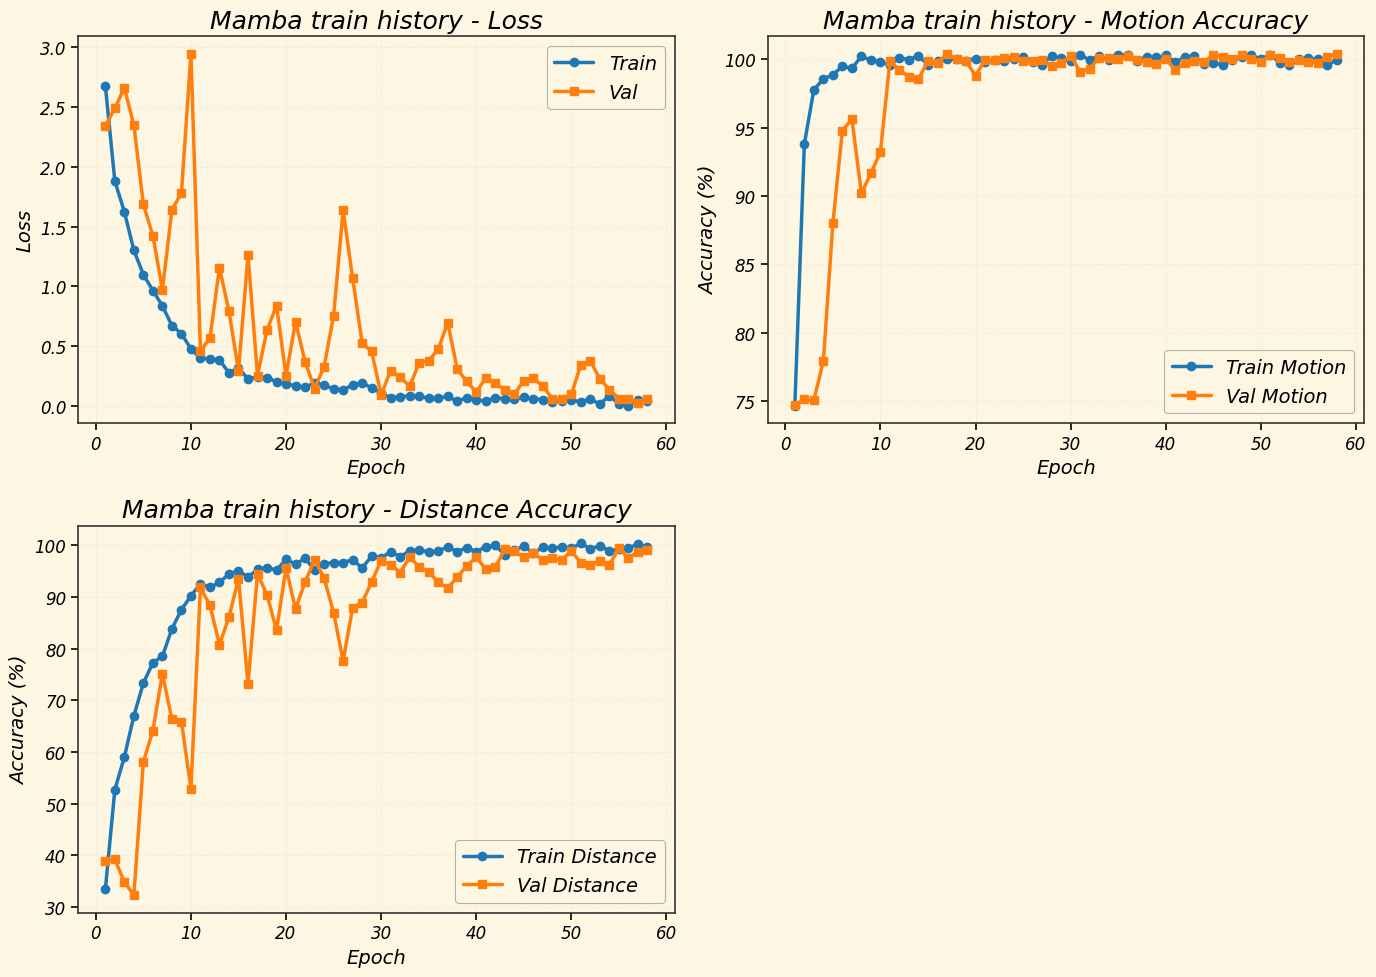

In [59]:
plot_training_history(trainer, title="Mamba train history")

### Evaluate

Evaluating Mamba-Attention: 100%|██████████| 1/1 [00:00<00:00, 11.93it/s]



Mamba-Attention - Motion Classification Report
              precision    recall  f1-score   support

 No movement       1.00      1.00      1.00        40
    Movement       1.00      1.00      1.00       120

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160


Mamba-Attention - Distance Classification Report
              precision    recall  f1-score   support

          0m       1.00      1.00      1.00        40
          1m       0.95      1.00      0.98        40
          2m       0.97      0.90      0.94        40
          3m       0.95      0.97      0.96        40

    accuracy                           0.97       160
   macro avg       0.97      0.97      0.97       160
weighted avg       0.97      0.97      0.97       160



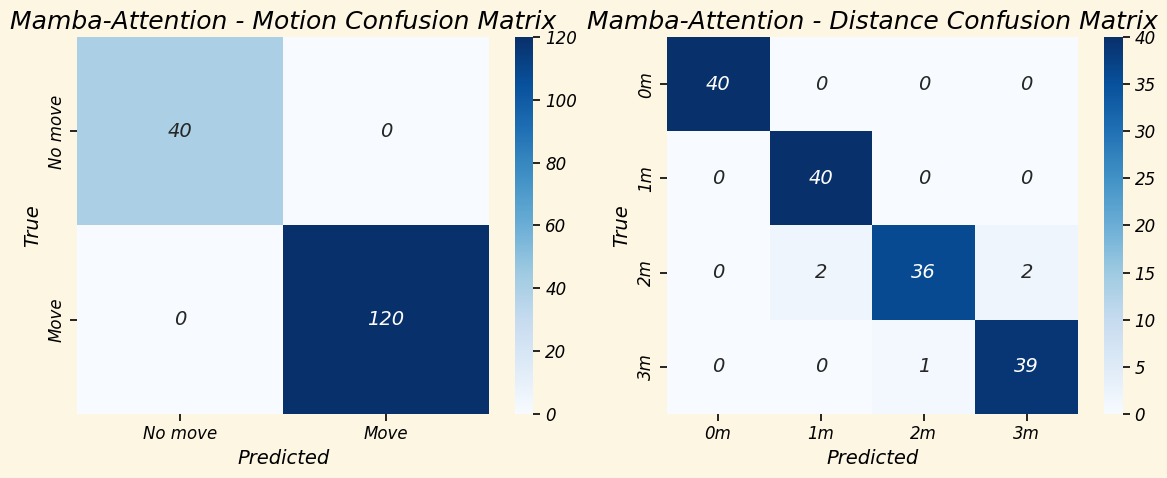

In [60]:
evaluate_model(model, test_loader, device, model_name="Mamba-Attention", is_mamba=True)